# Drug-Drug Interaction Extraction from Biomedical Text Using Relation Bio BERT with BiLSTM
## Reproduced Paper Methodology

In [ ]:
# CSV File generation from the raw DDICorpus Dataset
import xml.etree.ElementTree as ET
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# Label mapping (5 classes as in SemEval/paper)
LABEL_MAP = {'mechanism': 0, 'effect': 1, 'advice': 2, 'int': 3, 'false': 4}

def parse_ddi_folder(folder_path):
    rows = []
    for subdir in ['DrugBank', 'MedLine']:  # Or just one if needed
        path = os.path.join(folder_path, subdir)
        for filename in os.listdir(path):
            if not filename.endswith('.xml'): continue
            tree = ET.parse(os.path.join(path, filename))
            root = tree.getroot()
            for sentence in root.findall('sentence'):
                text = sentence.get('text')
                entities = {e.get('id'): e.get('text') for e in sentence.findall('entity')}
                for pair in sentence.findall('pair'):
                    e1_id = pair.get('e1')
                    e2_id = pair.get('e2')
                    if e1_id not in entities or e2_id not in entities: continue
                    drug1 = entities[e1_id]
                    drug2 = entities[e2_id]
                    ddi = pair.get('ddi') == 'true'
                    label_str = pair.get('type') if ddi else 'false'
                    label = LABEL_MAP.get(label_str, 4)  # Default to false
                    rows.append({'sentence': text, 'drug1': drug1, 'drug2': drug2, 'label': label})
    return pd.DataFrame(rows)

# Parse train and test
train_df = parse_ddi_folder('/kaggle/input/datasets/hareshkanaaramaraj/datasetnlp/DDICorpus/Train/')  # Adjust path if unzipped differently
test_df = parse_ddi_folder('/kaggle/input/datasets/hareshkanaaramaraj/datasetnlp/DDICorpus/Test/')

# Handle class imbalance (as in paper: filter negatives to ~1:2.3 positive:negative ratio)
positives = train_df[train_df['label'] != 4]
negatives = train_df[train_df['label'] == 4]
num_pos = len(positives)
num_neg_to_keep = int(num_pos * 2.3)  # Adjust ratio based on paper/experiments
negatives_filtered = negatives.sample(n=num_neg_to_keep, random_state=42)
train_filtered = pd.concat([positives, negatives_filtered]).sample(frac=1, random_state=42)

# Split train into train/val (80/20)
train_df, val_df = train_test_split(train_filtered, test_size=0.2, random_state=42)

# Save to CSV
train_df.to_csv('train_filtered.csv', index=False)
val_df.to_csv('val.csv', index=False)
test_df.to_csv('test.csv', index=False)

print(f"Train: {len(train_df)} samples | Val: {len(val_df)} | Test: {len(test_df)}")
print("Class distribution in train:", train_df['label'].value_counts())

Train: 8432 samples | Val: 2108 | Test: 5047
Class distribution in train: label
4    5859
1    1355
0    1061
3     157
Name: count, dtype: int64


## 1. Install Dependencies

In [ ]:
!pip install torch transformers pandas scikit-learn

In [ ]:
!pip install hf_xet

## 2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, classification_report
import re

# ==========================================
# CONFIGURATION
# ==========================================
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 5
LEARNING_RATE = 2e-5
NUM_CLASSES = 5
MODEL_NAME = "dmis-lab/biobert-v1.1" # Pre-trained BioBERT model

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 3. Load the Dataset & Data Pre-Processing

In [ ]:
# ==========================================
# 1. CUSTOM DATASET CLASS
# ==========================================
class DDIDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_len):
        self.data = pd.read_csv(csv_file)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def _tag_sentence(self, text, drug1, drug2):
        """
        Inserts <e1> and <e2> tags around the first occurrence of drug1 and drug2.
        """
        # Escape special characters in drug names to safely use in regex
        d1_esc = re.escape(str(drug1))
        d2_esc = re.escape(str(drug2))

        # Tag drug1 (first occurrence)
        text = re.sub(f"({d1_esc})", r"<e1>\1</e1>", str(text), count=1)
        # Tag drug2 (first occurrence)
        text = re.sub(f"({d2_esc})", r"<e2>\1</e2>", text, count=1)

        return text

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        text = str(row['sentence'])
        drug1 = str(row['drug1'])
        drug2 = str(row['drug2'])
        label = row['label']

        # 1. Add Tags if missing
        if "<e1>" not in text:
            text = self._tag_sentence(text, drug1, drug2)

        # 2. Tokenize
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        input_ids = encoding['input_ids'].flatten()
        attention_mask = encoding['attention_mask'].flatten()

        # 3. Create Entity Masks (e1_mask, e2_mask)
        e1_mask = torch.zeros(self.max_len)
        e2_mask = torch.zeros(self.max_len)

        # Convert ids back to tokens to find tags
        tokens = self.tokenizer.convert_ids_to_tokens(input_ids)

        try:
            # Find start/end of e1
            e1_start = tokens.index('<e1>')
            e1_end = tokens.index('</e1>')
            # Mark tokens between tags
            if e1_start + 1 < e1_end:
                e1_mask[e1_start+1 : e1_end] = 1

            # Find start/end of e2
            e2_start = tokens.index('<e2>')
            e2_end = tokens.index('</e2>')
            # Mark tokens between tags
            if e2_start + 1 < e2_end:
                e2_mask[e2_start+1 : e2_end] = 1
        except ValueError:
            # If tags got truncated or aren't found, fallback gracefully
            pass

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'e1_mask': e1_mask,
            'e2_mask': e2_mask,
            'labels': torch.tensor(label, dtype=torch.long)
        }

## 4. Model Architecture (R-BioBERT with BLSTM)

In [ ]:
# ==========================================
# 2. MODEL ARCHITECTURE (R-BioBERT with BLSTM)
# ==========================================
class RBioBERT_BLSTM(nn.Module):
    def __init__(self, num_classes):
        super(RBioBERT_BLSTM, self).__init__()
        self.biobert = AutoModel.from_pretrained(MODEL_NAME)
        self.hidden_size = self.biobert.config.hidden_size

        # Entity Activation Layer (W1, W2 in paper)
        self.fc_e1 = nn.Linear(self.hidden_size, self.hidden_size)
        self.fc_e2 = nn.Linear(self.hidden_size, self.hidden_size)
        self.activation = nn.Tanh()

        # Bidirectional LSTM
        # Input size is 2 * hidden_size (concatenated e1 and e2)
        self.lstm = nn.LSTM(input_size=2 * self.hidden_size,
                            hidden_size=self.hidden_size,
                            num_layers=1,
                            batch_first=True,
                            bidirectional=True)

        # Final Classification Layer
        # BLSTM output is 2 * hidden_size (forward + backward)
        self.fc_final = nn.Linear(2 * self.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask, e1_mask, e2_mask):
        # 1. BioBERT Output
        outputs = self.biobert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = outputs.last_hidden_state # [Batch, Seq_Len, Hidden]

        # 2. Extract Entity Embeddings
        # Multiply sequence output by mask to zero out non-entity tokens
        # Sum and divide by count to get average
        def get_entity_avg(mask):
            # mask: [Batch, Seq_Len] -> unsqueeze to [Batch, Seq_Len, 1]
            mask_expanded = mask.unsqueeze(-1)
            # Sum embeddings
            sum_embeddings = torch.sum(sequence_output * mask_expanded, dim=1)
            # Count tokens (avoid division by zero)
            sum_mask = torch.clamp(mask.sum(dim=1, keepdim=True), min=1e-9)
            return sum_embeddings / sum_mask

        e1_h = get_entity_avg(e1_mask) # [Batch, Hidden]
        e2_h = get_entity_avg(e2_mask) # [Batch, Hidden]

        # 3. Entity Processing (FC + Tanh)
        e1_h = self.activation(self.fc_e1(e1_h))
        e2_h = self.activation(self.fc_e2(e2_h))

        # 4. Concatenation
        combined = torch.cat((e1_h, e2_h), dim=1) # [Batch, 2*Hidden]

        # 5. BLSTM
        # LSTM expects [Batch, Seq, Feature]. We treat our concatenated vector as a sequence of length 1.
        combined = combined.unsqueeze(1) # [Batch, 1, 2*Hidden]
        lstm_out, _ = self.lstm(combined) # [Batch, 1, 2*Hidden]
        lstm_out = lstm_out.squeeze(1)    # [Batch, 2*Hidden]

        # 6. Classification
        logits = self.fc_final(lstm_out)
        return logits

## 5. Training and Evaluation Loop

In [ ]:
# ==========================================
# 3. TRAINING & EVALUATION LOOP
# ==========================================
def train_model():
    # Load Tokenizer and Add Special Tokens
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    special_tokens = {'additional_special_tokens': ['<e1>', '</e1>', '<e2>', '</e2>']}
    tokenizer.add_special_tokens(special_tokens)

    # Load Datasets
    train_dataset = DDIDataset('/kaggle/input/datasets/hareshkanaaramaraj/filess/train_filtered.csv', tokenizer, MAX_LEN)
    val_dataset = DDIDataset('/kaggle/input/datasets/hareshkanaaramaraj/filess/val.csv', tokenizer, MAX_LEN)
    test_dataset = DDIDataset('/kaggle/input/datasets/hareshkanaaramaraj/filess/test.csv', tokenizer, MAX_LEN)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

    # Initialize Model
    model = RBioBERT_BLSTM(NUM_CLASSES)
    model.biobert.resize_token_embeddings(len(tokenizer)) # Resize for new tags
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    # Training Loop
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        print(f"Epoch {epoch+1}/{EPOCHS}")

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            e1_mask = batch['e1_mask'].to(device)
            e2_mask = batch['e2_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask, e1_mask, e2_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        print(f"Training Loss: {avg_loss:.4f}")

        # Validation
        evaluate(model, val_loader, "Validation")

    # Final Test
    evaluate(model, test_loader, "Test")

def evaluate(model, loader, phase_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            e1_mask = batch['e1_mask'].to(device)
            e2_mask = batch['e2_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask, e1_mask, e2_mask)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate Metrics
    # Note: Use 'macro' or 'weighted' based on your class balance preference
    f1 = f1_score(all_labels, all_preds, average='macro')
    print(f"{phase_name} F1-Macro Score: {f1:.4f}")
    print(classification_report(all_labels, all_preds))

if __name__ == "__main__":
    train_model()

config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Epoch 1/5
Training Loss: 0.5235
Validation F1-Macro Score: 0.8819
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       261
           1       0.90      0.89      0.89       316
           3       0.81      0.86      0.84        44
           4       0.96      0.95      0.96      1487

    accuracy                           0.93      2108
   macro avg       0.87      0.89      0.88      2108
weighted avg       0.93      0.93      0.93      2108

Epoch 2/5
Training Loss: 0.2450
Validation F1-Macro Score: 0.8971
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       261
           1       0.87      0.93      0.90       316
           3       0.85      0.93      0.89        44
           4       0.98      0.94      0.96      1487

    accuracy                           0.93      2108
   macro avg       0.87      0.92      0.90      2108
weighted avg       0.93      0.93      0.93      2108

# I. Fine-Tuning BioBERT with LoRA

This section implements **LoRA (Low-Rank Adaptation)** applied directly to the
BioBERT encoder inside the `RBioBERT_BLSTM` architecture.  

**Key ideas:**
- The pre-trained BioBERT weights are **frozen** — only the small LoRA adapter
  matrices `A` and `B` (plus the task-specific head layers) are trained.
- LoRA is injected into every **Query** and **Value** projection of every
  BERT attention layer (`query` and `value` in each of the 12 transformer blocks).
- This reduces trainable parameters from ~109 M (full BioBERT) to roughly
  **~1–3 M**, enabling faster, memory-efficient fine-tuning on the DDI corpus.
- The BLSTM + classification head from the baseline model are kept unchanged
  so results remain directly comparable to the paper.

### LoRA mathematics
For a frozen weight matrix $W_0 \in \mathbb{R}^{d \times k}$, LoRA adds:
$$h = W_0 x + \frac{\alpha}{r} B A x$$
where $A \in \mathbb{R}^{r \times k}$ and $B \in \mathbb{R}^{d \times r}$ are
the trainable low-rank matrices, $r \ll \min(d,k)$ is the rank, and
$\alpha$ is a scaling hyper-parameter.

### Hyper-parameters used
| Hyper-parameter | Value | Meaning |
|---|---|---|
| `LORA_R` | 8 | Rank of decomposition |
| `LORA_ALPHA` | 16 | Scaling factor |
| `LORA_DROPOUT` | 0.1 | Dropout on adapter path |
| Target modules | `query`, `value` | Attention projections adapted |

In [ ]:
# =============================================================================
# CONTRIBUTION: Fine-Tuning BioBERT with LoRA (Low-Rank Adaptation)
# =============================================================================

import math
import copy
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, classification_report

# ---------------------------------------------------------------------------
# LoRA Hyper-parameters
# ---------------------------------------------------------------------------
LORA_R       = 8
LORA_ALPHA   = 16
LORA_DROPOUT = 0.1
LORA_TARGETS = ["query", "value"]

# ---------------------------------------------------------------------------
# 1. LoRALinear
# ---------------------------------------------------------------------------
class LoRALinear(nn.Module):
    def __init__(self, base_layer: nn.Linear, r: int = 8,
                 alpha: float = 16, dropout: float = 0.1):
        super().__init__()
        in_f  = base_layer.in_features
        out_f = base_layer.out_features

        self.base_layer = base_layer
        for p in self.base_layer.parameters():
            p.requires_grad = False

        self.lora_A  = nn.Linear(in_f, r,     bias=False)
        self.lora_B  = nn.Linear(r,    out_f, bias=False)
        self.scale   = alpha / r
        self.dropout = nn.Dropout(p=dropout)

        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        base_out = self.base_layer(x)
        lora_out = self.lora_B(self.lora_A(self.dropout(x))) * self.scale
        return base_out + lora_out

    def extra_repr(self):
        return (f"in={self.base_layer.in_features}, "
                f"out={self.base_layer.out_features}, "
                f"r={self.lora_A.out_features}, scale={self.scale:.3f}")


# ---------------------------------------------------------------------------
# 2. Inject LoRA into BioBERT attention layers
# ---------------------------------------------------------------------------
def inject_lora_into_biobert(biobert_model, target_names, r, alpha, dropout):
    num_injected = 0
    for layer in biobert_model.encoder.layer:
        attn_self = layer.attention.self
        for name in target_names:
            if hasattr(attn_self, name):
                original = getattr(attn_self, name)
                if isinstance(original, nn.Linear):
                    setattr(attn_self, name,
                            LoRALinear(original, r=r, alpha=alpha, dropout=dropout))
                    num_injected += 1
    print(f"[LoRA] Injected adapters into {num_injected} projections "
          f"across {len(biobert_model.encoder.layer)} transformer layers.")
    return biobert_model


# ---------------------------------------------------------------------------
# 3. Count parameters
# ---------------------------------------------------------------------------
def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total parameters      : {total:>12,}")
    print(f"  Trainable (LoRA+head) : {trainable:>12,}  ({100*trainable/total:.2f}%)")
    print(f"  Frozen  (BioBERT W0)  : {total - trainable:>12,}")


# ---------------------------------------------------------------------------
# 4. RBioBERT_LoRA_BLSTM
# ---------------------------------------------------------------------------
class RBioBERT_LoRA_BLSTM(nn.Module):
    def __init__(self, num_classes,
                 lora_r=LORA_R, lora_alpha=LORA_ALPHA,
                 lora_dropout=LORA_DROPOUT, lora_targets=LORA_TARGETS):
        super().__init__()

        self.biobert     = AutoModel.from_pretrained(MODEL_NAME)
        self.hidden_size = self.biobert.config.hidden_size

        for p in self.biobert.parameters():
            p.requires_grad = False

        self.biobert = inject_lora_into_biobert(
            self.biobert, lora_targets, lora_r, lora_alpha, lora_dropout)

        self.fc_e1      = nn.Linear(self.hidden_size, self.hidden_size)
        self.fc_e2      = nn.Linear(self.hidden_size, self.hidden_size)
        self.activation = nn.Tanh()
        self.lstm       = nn.LSTM(input_size=2 * self.hidden_size,
                                  hidden_size=self.hidden_size,
                                  num_layers=1, batch_first=True,
                                  bidirectional=True)
        self.dropout    = nn.Dropout(p=lora_dropout)
        self.fc_final   = nn.Linear(2 * self.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask, e1_mask, e2_mask):
        sequence_output = self.biobert(
            input_ids=input_ids,
            attention_mask=attention_mask
        ).last_hidden_state                                  # [B, L, H]

        def entity_avg(mask):
            mask_exp = mask.unsqueeze(-1)
            sum_emb  = torch.sum(sequence_output * mask_exp, dim=1)
            sum_mask = torch.clamp(mask.sum(1, keepdim=True), min=1e-9)
            return sum_emb / sum_mask

        e1_h = self.activation(self.fc_e1(entity_avg(e1_mask)))
        e2_h = self.activation(self.fc_e2(entity_avg(e2_mask)))

        combined    = self.dropout(torch.cat((e1_h, e2_h), dim=1))
        lstm_out, _ = self.lstm(combined.unsqueeze(1))
        lstm_out    = lstm_out.squeeze(1)

        return self.fc_final(lstm_out)


# ---------------------------------------------------------------------------
# 5. Evaluation helper (fixed: explicit labels list prevents ValueError)
# ---------------------------------------------------------------------------
def evaluate_lora(model, loader, phase_name, verbose=True):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            e1_mask        = batch['e1_mask'].to(device)
            e2_mask        = batch['e2_mask'].to(device)
            labels         = batch['labels'].to(device)

            preds = torch.argmax(
                model(input_ids, attention_mask, e1_mask, e2_mask), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    label_indices = [0, 1, 2, 3, 4]
    label_names   = ['mechanism', 'effect', 'advice', 'int', 'false']

    f1_macro    = f1_score(all_labels, all_preds, average='macro',
                           labels=label_indices, zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted',
                           labels=label_indices, zero_division=0)

    if verbose:
        print(f"\n{phase_name} | F1-Macro: {f1_macro:.4f}  |  F1-Weighted: {f1_weighted:.4f}")
        print(classification_report(all_labels, all_preds,
                                    labels=label_indices,
                                    target_names=label_names,
                                    zero_division=0))
    return f1_macro


# ---------------------------------------------------------------------------
# 6. Training function
# ---------------------------------------------------------------------------
def train_lora_model():
    print("=" * 60)
    print("  Training: R-BioBERT + LoRA + BLSTM  (Contribution)")
    print("=" * 60)

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    tokenizer.add_special_tokens(
        {'additional_special_tokens': ['<e1>', '</e1>', '<e2>', '</e2>']})

    train_loader = DataLoader(
        DDIDataset('/kaggle/input/datasets/hareshkanaaramaraj/filess/train_filtered.csv',
                   tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(
        DDIDataset('/kaggle/input/datasets/hareshkanaaramaraj/filess/val.csv',
                   tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
    test_loader = DataLoader(
        DDIDataset('/kaggle/input/datasets/hareshkanaaramaraj/filess/test.csv',
                   tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

    model = RBioBERT_LoRA_BLSTM(num_classes=NUM_CLASSES)
    model.biobert.resize_token_embeddings(len(tokenizer))
    model.to(device)

    print("\n[Parameter budget]")
    count_parameters(model)

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()

    best_val_f1, patience_count, best_state = 0.0, 0, None
    PATIENCE = 3

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            e1_mask        = batch['e1_mask'].to(device)
            e2_mask        = batch['e2_mask'].to(device)
            labels         = batch['labels'].to(device)

            optimizer.zero_grad()
            loss = criterion(
                model(input_ids, attention_mask, e1_mask, e2_mask), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, model.parameters()), 1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        avg_loss = total_loss / len(train_loader)
        val_f1   = evaluate_lora(model, val_loader, "Validation", verbose=False)

        print(f"Epoch [{epoch:02d}/{EPOCHS}]  "
              f"Loss: {avg_loss:.4f}  |  Val F1-Macro: {val_f1:.4f}  |  "
              f"LR: {scheduler.get_last_lr()[0]:.2e}")

        if val_f1 > best_val_f1:
            best_val_f1    = val_f1
            best_state     = copy.deepcopy(model.state_dict())
            patience_count = 0
            print(f"           ✓ Best Val F1-Macro: {best_val_f1:.4f}  (checkpoint saved)")
        else:
            patience_count += 1
            if patience_count >= PATIENCE:
                print(f"\nEarly stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)

    print("\n" + "=" * 60)
    print("  Final Test Evaluation  (LoRA model)")
    print("=" * 60)
    evaluate_lora(model, test_loader, "Test", verbose=True)

    torch.save(model.state_dict(), 'rbiobert_lora_blstm_best.pt')
    print("\n[Saved] rbiobert_lora_blstm_best.pt")
    return model


# ---------------------------------------------------------------------------
# 7. Run
# ---------------------------------------------------------------------------
lora_model = train_lora_model()

  Training: R-BioBERT + LoRA + BLSTM  (Contribution)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[LoRA] Injected adapters into 24 projections across 12 transformer layers.

[Parameter budget]
  Total parameters      :  123,965,189
  Trainable (LoRA+head) :   15,651,845  (12.63%)
  Frozen  (BioBERT W0)  :  108,313,344
Epoch [01/5]  Loss: 0.8676  |  Val F1-Macro: 0.3929  |  LR: 1.82e-05
           ✓ Best Val F1-Macro: 0.3929  (checkpoint saved)
Epoch [02/5]  Loss: 0.5548  |  Val F1-Macro: 0.5037  |  LR: 1.34e-05
           ✓ Best Val F1-Macro: 0.5037  (checkpoint saved)
Epoch [03/5]  Loss: 0.4559  |  Val F1-Macro: 0.5977  |  LR: 7.56e-06
           ✓ Best Val F1-Macro: 0.5977  (checkpoint saved)
Epoch [04/5]  Loss: 0.4070  |  Val F1-Macro: 0.6173  |  LR: 2.81e-06
           ✓ Best Val F1-Macro: 0.6173  (checkpoint saved)
Epoch [05/5]  Loss: 0.3856  |  Val F1-Macro: 0.6290  |  LR: 1.00e-06
           ✓ Best Val F1-Macro: 0.6290  (checkpoint saved)

  Final Test Evaluation  (LoRA model)

Test | F1-Macro: 0.5833  |  F1-Weighted: 0.9166
              precision    recall  f1-score   supp

# II. Replacing BioBERT with BiGRU

In [ ]:
# =============================================================================
# CONTRIBUTION 2: Replace BioBERT with BiGRU
# =============================================================================
# Architecture change:
#   - BioBERT encoder is fully removed
#   - A two-layer Bidirectional GRU acts as the sequence encoder instead
#   - Word embeddings (randomly initialised, trainable) replace BERT embeddings
#   - The rest of the pipeline (entity avg-pool → FC+Tanh → concat →
#     BLSTM → classifier) remains identical to the paper (Figure 1)
#
# Why BiGRU?
#   - Lighter and faster than BERT-based models (~10x fewer parameters)
#   - Captures bidirectional sequential context like BioBERT but without
#     the transformer attention overhead
#   - Serves as a strong RNN baseline to compare against the LoRA model
# =============================================================================

import copy
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, classification_report
import pandas as pd
import re

# ---------------------------------------------------------------------------
# Hyper-parameters
# ---------------------------------------------------------------------------
BIGRU_EMBED_DIM  = 256    # word embedding dimension
BIGRU_HIDDEN     = 384    # GRU hidden size  (BiGRU output = 2 × 384 = 768)
BIGRU_LAYERS     = 2      # stacked GRU layers
BIGRU_DROPOUT    = 0.3
BIGRU_PATIENCE   = 3

# Vocab will be built from training data
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'

# ---------------------------------------------------------------------------
# 1. Vocabulary builder
# ---------------------------------------------------------------------------
def build_vocab(csv_files, min_freq=2):
    """
    Build a word-level vocabulary from tagged sentence columns
    across one or more CSV files.

    Parameters
    ----------
    csv_files : list[str]  – paths to train/val CSVs
    min_freq  : int        – minimum token frequency to include

    Returns
    -------
    word2idx : dict[str, int]
    """
    from collections import Counter
    counter = Counter()
    for path in csv_files:
        df = pd.read_csv(path)
        for text in df['sentence'].dropna():
            tokens = str(text).lower().split()
            counter.update(tokens)

    word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            word2idx[word] = len(word2idx)

    print(f"[Vocab] Size: {len(word2idx):,}  "
          f"(min_freq={min_freq}, from {len(csv_files)} file(s))")
    return word2idx


# ---------------------------------------------------------------------------
# 2. Dataset for BiGRU (token-index based, no BERT tokeniser needed)
# ---------------------------------------------------------------------------
class DDIDatasetGRU(Dataset):
    """
    Tokenises sentences into integer indices for BiGRU input.
    Entity masks mark the positions of <e1> and <e2> drug tokens.
    """
    def __init__(self, csv_file, word2idx, max_len):
        self.data     = pd.read_csv(csv_file)
        self.word2idx = word2idx
        self.max_len  = max_len

    def _tag_sentence(self, text, drug1, drug2):
        d1_esc = re.escape(str(drug1))
        d2_esc = re.escape(str(drug2))
        text   = re.sub(f"({d1_esc})", r"<e1>\1</e1>", str(text), count=1)
        text   = re.sub(f"({d2_esc})", r"<e2>\1</e2>", text,      count=1)
        return text

    def _encode(self, text):
        tokens = str(text).lower().split()[:self.max_len]
        ids    = [self.word2idx.get(t, 1) for t in tokens]   # 1 = UNK
        # Pad to max_len
        pad_len = self.max_len - len(ids)
        ids    += [0] * pad_len                               # 0 = PAD
        return ids, len(tokens)                               # ids, actual length

    def _entity_mask(self, text, open_tag, close_tag):
        """Returns a binary mask of length max_len marking entity token positions."""
        mask   = torch.zeros(self.max_len)
        tokens = str(text).lower().split()
        inside = False
        pos    = 0
        for tok in tokens:
            if pos >= self.max_len:
                break
            if open_tag in tok:
                inside = True
            if inside and open_tag not in tok and close_tag not in tok:
                mask[pos] = 1
                pos += 1
            elif inside and close_tag in tok:
                inside = False
            elif not inside:
                pos += 1
        return mask

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data.iloc[idx]
        text  = str(row['sentence'])
        drug1 = str(row['drug1'])
        drug2 = str(row['drug2'])
        label = int(row['label'])

        if '<e1>' not in text:
            text = self._tag_sentence(text, drug1, drug2)

        ids, seq_len = self._encode(text)
        e1_mask      = self._entity_mask(text, '<e1>', '</e1>')
        e2_mask      = self._entity_mask(text, '<e2>', '</e2>')

        return {
            'input_ids':  torch.tensor(ids,     dtype=torch.long),
            'seq_len':    torch.tensor(seq_len, dtype=torch.long),
            'e1_mask':    e1_mask,
            'e2_mask':    e2_mask,
            'labels':     torch.tensor(label,   dtype=torch.long)
        }


# ---------------------------------------------------------------------------
# 3. BiGRU_BLSTM model
# ---------------------------------------------------------------------------
class BiGRU_BLSTM(nn.Module):
    """
    DDI extraction model with BiGRU replacing BioBERT.

    Architecture (mirrors Figure 1 of the paper):
        Token embeddings  [B, L, E]
            │
        2-layer Bidirectional GRU                [B, L, 2·H_gru]
            │  sequence_output
        Entity avg-pool + FC + Tanh  →  H1', H2' [B, 2·H_gru] each
            │
        Concat [H1' ⊕ H2']                        [B, 4·H_gru]
            │
        BLSTM                                      [B, 2·H_gru]
            │
        FC + Softmax  →  DDI label
    """
    def __init__(self, vocab_size, num_classes,
                 embed_dim   = BIGRU_EMBED_DIM,
                 gru_hidden  = BIGRU_HIDDEN,
                 gru_layers  = BIGRU_LAYERS,
                 dropout     = BIGRU_DROPOUT):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embed_drop = nn.Dropout(p=dropout)

        # Bidirectional GRU encoder (replaces BioBERT)
        self.bigru = nn.GRU(
            input_size   = embed_dim,
            hidden_size  = gru_hidden,
            num_layers   = gru_layers,
            batch_first  = True,
            bidirectional= True,
            dropout      = dropout if gru_layers > 1 else 0.0
        )

        gru_out_dim = 2 * gru_hidden   # bidirectional output size

        # Entity FC layers  (Equations 1 & 2 in paper)
        self.fc_e1    = nn.Linear(gru_out_dim, gru_out_dim)
        self.fc_e2    = nn.Linear(gru_out_dim, gru_out_dim)
        self.activation = nn.Tanh()

        # BLSTM  (Equations 3–9 in paper)
        self.lstm = nn.LSTM(
            input_size   = 2 * gru_out_dim,   # concat of e1 + e2
            hidden_size  = gru_out_dim,
            num_layers   = 1,
            batch_first  = True,
            bidirectional= True
        )

        self.dropout  = nn.Dropout(p=dropout)
        # BLSTM output dim = 2 * gru_out_dim
        self.fc_final = nn.Linear(2 * gru_out_dim, num_classes)

    def forward(self, input_ids, seq_len, e1_mask, e2_mask):
        # 1. Embeddings
        x = self.embed_drop(self.embedding(input_ids))   # [B, L, E]

        # 2. BiGRU encoder
        packed  = nn.utils.rnn.pack_padded_sequence(
            x, seq_len.cpu(), batch_first=True, enforce_sorted=False)
        gru_out, _ = self.bigru(packed)
        gru_out, _ = nn.utils.rnn.pad_packed_sequence(
            gru_out, batch_first=True,
            total_length=input_ids.size(1))               # [B, L, 2·H]

        # 3. Entity average pooling
        def entity_avg(mask):
            mask_exp = mask.unsqueeze(-1).to(gru_out.device)  # [B, L, 1]
            sum_emb  = torch.sum(gru_out * mask_exp, dim=1)   # [B, 2H]
            sum_mask = torch.clamp(mask.sum(1, keepdim=True).to(
                                   gru_out.device), min=1e-9)
            return sum_emb / sum_mask

        e1_h = self.activation(self.fc_e1(entity_avg(e1_mask)))  # [B, 2H]
        e2_h = self.activation(self.fc_e2(entity_avg(e2_mask)))  # [B, 2H]

        # 4. Concat → BLSTM
        combined    = self.dropout(torch.cat((e1_h, e2_h), dim=1))  # [B, 4H]
        lstm_out, _ = self.lstm(combined.unsqueeze(1))               # [B, 1, 2·2H]
        lstm_out    = lstm_out.squeeze(1)                            # [B, 2·2H]

        # 5. Classifier
        return self.fc_final(lstm_out)


# ---------------------------------------------------------------------------
# 4. Count parameters
# ---------------------------------------------------------------------------
def count_parameters_gru(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total parameters  : {total:>10,}")
    print(f"  Trainable         : {trainable:>10,}  ({100*trainable/total:.2f}%)")


# ---------------------------------------------------------------------------
# 5. Evaluation helper
# ---------------------------------------------------------------------------
def evaluate_gru(model, loader, phase_name, verbose=True):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            seq_len   = batch['seq_len'].to(device)
            e1_mask   = batch['e1_mask'].to(device)
            e2_mask   = batch['e2_mask'].to(device)
            labels    = batch['labels'].to(device)

            preds = torch.argmax(
                model(input_ids, seq_len, e1_mask, e2_mask), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    label_indices = [0, 1, 2, 3, 4]
    label_names   = ['mechanism', 'effect', 'advice', 'int', 'false']

    f1_macro    = f1_score(all_labels, all_preds, average='macro',
                           labels=label_indices, zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted',
                           labels=label_indices, zero_division=0)

    if verbose:
        print(f"\n{phase_name} | F1-Macro: {f1_macro:.4f}  |  "
              f"F1-Weighted: {f1_weighted:.4f}")
        print(classification_report(all_labels, all_preds,
                                    labels=label_indices,
                                    target_names=label_names,
                                    zero_division=0))
    return f1_macro


# ---------------------------------------------------------------------------
# 6. Training function
# ---------------------------------------------------------------------------
def train_bigru_model():
    print("=" * 60)
    print("  Training: BiGRU + BLSTM  (Contribution 2)")
    print("=" * 60)

    TRAIN_CSV = '/kaggle/input/datasets/hareshkanaaramaraj/filess/train_filtered.csv'
    VAL_CSV   = '/kaggle/input/datasets/hareshkanaaramaraj/filess/val.csv'
    TEST_CSV  = '/kaggle/input/datasets/hareshkanaaramaraj/filess/test.csv'

    # Build vocabulary from train + val
    word2idx = build_vocab([TRAIN_CSV, VAL_CSV], min_freq=2)
    vocab_size = len(word2idx)

    # Datasets & loaders
    train_loader = DataLoader(
        DDIDatasetGRU(TRAIN_CSV, word2idx, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(
        DDIDatasetGRU(VAL_CSV, word2idx, MAX_LEN),
        batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
    test_loader = DataLoader(
        DDIDatasetGRU(TEST_CSV, word2idx, MAX_LEN),
        batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

    # Model
    model = BiGRU_BLSTM(vocab_size=vocab_size, num_classes=NUM_CLASSES)
    model.to(device)

    print("\n[Parameter budget]")
    count_parameters_gru(model)

    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=LEARNING_RATE, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()

    best_val_f1, patience_count, best_state = 0.0, 0, None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            seq_len   = batch['seq_len'].to(device)
            e1_mask   = batch['e1_mask'].to(device)
            e2_mask   = batch['e2_mask'].to(device)
            labels    = batch['labels'].to(device)

            optimizer.zero_grad()
            loss = criterion(
                model(input_ids, seq_len, e1_mask, e2_mask), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        avg_loss = total_loss / len(train_loader)
        val_f1   = evaluate_gru(model, val_loader, "Validation", verbose=False)

        print(f"Epoch [{epoch:02d}/{EPOCHS}]  "
              f"Loss: {avg_loss:.4f}  |  Val F1-Macro: {val_f1:.4f}  |  "
              f"LR: {scheduler.get_last_lr()[0]:.2e}")

        if val_f1 > best_val_f1:
            best_val_f1    = val_f1
            best_state     = copy.deepcopy(model.state_dict())
            patience_count = 0
            print(f"           ✓ Best Val F1-Macro: {best_val_f1:.4f}  "
                  f"(checkpoint saved)")
        else:
            patience_count += 1
            if patience_count >= BIGRU_PATIENCE:
                print(f"\nEarly stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)

    print("\n" + "=" * 60)
    print("  Final Test Evaluation  (BiGRU model)")
    print("=" * 60)
    evaluate_gru(model, test_loader, "Test", verbose=True)

    torch.save(model.state_dict(), 'bigru_blstm_best.pt')
    print("\n[Saved] bigru_blstm_best.pt")
    return model


# ---------------------------------------------------------------------------
# 7. Run
# ---------------------------------------------------------------------------
bigru_model = train_bigru_model()

  Training: BiGRU + BLSTM  (Contribution 2)
[Vocab] Size: 7,034  (min_freq=2, from 2 file(s))

[Parameter budget]
  Total parameters  : 21,295,621
  Trainable         : 21,295,621  (100.00%)
Epoch [01/5]  Loss: 1.1273  |  Val F1-Macro: 0.1655  |  LR: 1.82e-05
           ✓ Best Val F1-Macro: 0.1655  (checkpoint saved)
Epoch [02/5]  Loss: 0.8846  |  Val F1-Macro: 0.1706  |  LR: 1.34e-05
           ✓ Best Val F1-Macro: 0.1706  (checkpoint saved)
Epoch [03/5]  Loss: 0.8725  |  Val F1-Macro: 0.1779  |  LR: 7.56e-06
           ✓ Best Val F1-Macro: 0.1779  (checkpoint saved)
Epoch [04/5]  Loss: 0.8673  |  Val F1-Macro: 0.1860  |  LR: 2.81e-06
           ✓ Best Val F1-Macro: 0.1860  (checkpoint saved)
Epoch [05/5]  Loss: 0.8648  |  Val F1-Macro: 0.1827  |  LR: 1.00e-06

  Final Test Evaluation  (BiGRU model)

Test | F1-Macro: 0.2081  |  F1-Weighted: 0.8373
              precision    recall  f1-score   support

   mechanism       0.00      0.00      0.00      1319
      effect       0.43      0

# III. BiGRU with Attention Mechanism

In [ ]:
# =============================================================================
# CONTRIBUTION 3: BiGRU with Attention Mechanism
# =============================================================================
# Architecture change over Contribution 2 (plain BiGRU):
#   - A token-level attention layer is added on top of the BiGRU output
#     before entity avg-pooling.
#   - Attention computes a softmax score for every token position and
#     produces a weighted context vector, allowing the model to focus on
#     the most informative tokens for DDI classification.
#   - Everything downstream (entity avg-pool → FC+Tanh → concat →
#     BLSTM → classifier) remains identical to Figure 1 of the paper.
#
# Attention formula:
#   e_t  = tanh(W_a · h_t + b_a)        score (unnormalised)
#   α_t  = softmax(e_t)                  attention weight
#   c    = Σ α_t · h_t                   context vector
# =============================================================================

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, classification_report
import pandas as pd
import re

# ---------------------------------------------------------------------------
# Hyper-parameters
# ---------------------------------------------------------------------------
BIGRU_ATT_EMBED_DIM  = 256
BIGRU_ATT_HIDDEN     = 384    # BiGRU output = 2 × 384 = 768
BIGRU_ATT_LAYERS     = 2
BIGRU_ATT_DROPOUT    = 0.3
BIGRU_ATT_PATIENCE   = 3

PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'


# ---------------------------------------------------------------------------
# 1. Vocabulary builder  (reused from Contribution 2)
# ---------------------------------------------------------------------------
def build_vocab(csv_files, min_freq=2):
    from collections import Counter
    counter = Counter()
    for path in csv_files:
        df = pd.read_csv(path)
        for text in df['sentence'].dropna():
            counter.update(str(text).lower().split())

    word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    for word, freq in counter.items():
        if freq >= min_freq:
            word2idx[word] = len(word2idx)

    print(f"[Vocab] Size: {len(word2idx):,}  (min_freq={min_freq})")
    return word2idx


# ---------------------------------------------------------------------------
# 2. Dataset  (reused from Contribution 2)
# ---------------------------------------------------------------------------
class DDIDatasetGRU(Dataset):
    def __init__(self, csv_file, word2idx, max_len):
        self.data     = pd.read_csv(csv_file)
        self.word2idx = word2idx
        self.max_len  = max_len

    def _tag_sentence(self, text, drug1, drug2):
        d1_esc = re.escape(str(drug1))
        d2_esc = re.escape(str(drug2))
        text   = re.sub(f"({d1_esc})", r"<e1>\1</e1>", str(text), count=1)
        text   = re.sub(f"({d2_esc})", r"<e2>\1</e2>", text,      count=1)
        return text

    def _encode(self, text):
        tokens  = str(text).lower().split()[:self.max_len]
        ids     = [self.word2idx.get(t, 1) for t in tokens]
        pad_len = self.max_len - len(ids)
        ids    += [0] * pad_len
        return ids, len(tokens)

    def _entity_mask(self, text, open_tag, close_tag):
        mask   = torch.zeros(self.max_len)
        tokens = str(text).lower().split()
        inside = False
        pos    = 0
        for tok in tokens:
            if pos >= self.max_len:
                break
            if open_tag in tok:
                inside = True
            if inside and open_tag not in tok and close_tag not in tok:
                mask[pos] = 1
                pos += 1
            elif inside and close_tag in tok:
                inside = False
            elif not inside:
                pos += 1
        return mask

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data.iloc[idx]
        text  = str(row['sentence'])
        drug1 = str(row['drug1'])
        drug2 = str(row['drug2'])
        label = int(row['label'])

        if '<e1>' not in text:
            text = self._tag_sentence(text, drug1, drug2)

        ids, seq_len = self._encode(text)
        e1_mask      = self._entity_mask(text, '<e1>', '</e1>')
        e2_mask      = self._entity_mask(text, '<e2>', '</e2>')

        return {
            'input_ids': torch.tensor(ids,     dtype=torch.long),
            'seq_len':   torch.tensor(seq_len, dtype=torch.long),
            'e1_mask':   e1_mask,
            'e2_mask':   e2_mask,
            'labels':    torch.tensor(label,   dtype=torch.long)
        }


# ---------------------------------------------------------------------------
# 3. Token-level Attention layer
# ---------------------------------------------------------------------------
class TokenAttention(nn.Module):
    """
    Additive (Bahdanau-style) token-level attention over BiGRU outputs.

    Given hidden states H ∈ R^{B × L × d}:
        score_t = tanh( W_a · h_t + b_a )        ∈ R^{B × L × 1}
        α       = softmax(score, dim=1)            ∈ R^{B × L × 1}
        context = Σ_t  α_t · h_t                  ∈ R^{B × d}

    The attention weights α are also returned so they can be
    inspected or used for entity-aware pooling.
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn   = nn.Linear(hidden_dim, 1, bias=True)

    def forward(self, gru_out: torch.Tensor,
                pad_mask: torch.Tensor = None):
        """
        Parameters
        ----------
        gru_out  : [B, L, d]  – BiGRU hidden states
        pad_mask : [B, L]     – 1 for real tokens, 0 for padding (optional)

        Returns
        -------
        context  : [B, d]     – attention-weighted context vector
        alpha    : [B, L]     – attention weights
        """
        # Raw scores
        scores = self.attn(torch.tanh(gru_out))       # [B, L, 1]
        scores = scores.squeeze(-1)                    # [B, L]

        # Mask padding positions with -inf before softmax
        if pad_mask is not None:
            scores = scores.masked_fill(pad_mask == 0, float('-inf'))

        alpha   = F.softmax(scores, dim=1)             # [B, L]
        context = torch.bmm(alpha.unsqueeze(1),
                            gru_out).squeeze(1)        # [B, d]
        return context, alpha


# ---------------------------------------------------------------------------
# 4. BiGRU_Attention_BLSTM model
# ---------------------------------------------------------------------------
class BiGRU_Attention_BLSTM(nn.Module):
    """
    DDI extraction with BiGRU + token-level attention replacing BioBERT.

    Pipeline (Figure 1 of the paper, with attention added):

        Token embeddings          [B, L, E]
              │
        2-layer Bidirectional GRU [B, L, 2·H]
              │
        Token Attention           → context vector  [B, 2·H]
              │                   → alpha weights   [B, L]
        Entity avg-pool (attention-weighted)
              │   H1', H2'        [B, 2·H] each
        FC + Tanh
              │
        Concat [H1' ⊕ H2']        [B, 4·H]
              │
        BLSTM                     [B, 2·(2·H)]
              │
        FC + Softmax → DDI label
    """
    def __init__(self, vocab_size, num_classes,
                 embed_dim  = BIGRU_ATT_EMBED_DIM,
                 gru_hidden = BIGRU_ATT_HIDDEN,
                 gru_layers = BIGRU_ATT_LAYERS,
                 dropout    = BIGRU_ATT_DROPOUT):
        super().__init__()

        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embed_drop = nn.Dropout(p=dropout)

        # Bidirectional GRU encoder
        self.bigru = nn.GRU(
            input_size    = embed_dim,
            hidden_size   = gru_hidden,
            num_layers    = gru_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if gru_layers > 1 else 0.0
        )

        gru_out_dim = 2 * gru_hidden          # 768 (matches BioBERT dim)

        # Token-level attention
        self.attention = TokenAttention(gru_out_dim)

        # Entity FC layers  (Equations 1 & 2 in paper)
        self.fc_e1      = nn.Linear(gru_out_dim, gru_out_dim)
        self.fc_e2      = nn.Linear(gru_out_dim, gru_out_dim)
        self.activation = nn.Tanh()

        # BLSTM  (Equations 3–9 in paper)
        self.lstm = nn.LSTM(
            input_size    = 2 * gru_out_dim,
            hidden_size   = gru_out_dim,
            num_layers    = 1,
            batch_first   = True,
            bidirectional = True
        )

        self.dropout  = nn.Dropout(p=dropout)
        self.fc_final = nn.Linear(2 * gru_out_dim, num_classes)

    # ------------------------------------------------------------------
    def forward(self, input_ids, seq_len, e1_mask, e2_mask):
        # 1. Embeddings
        x = self.embed_drop(self.embedding(input_ids))      # [B, L, E]

        # 2. BiGRU encoder
        packed     = nn.utils.rnn.pack_padded_sequence(
            x, seq_len.cpu(), batch_first=True, enforce_sorted=False)
        gru_out, _ = self.bigru(packed)
        gru_out, _ = nn.utils.rnn.pad_packed_sequence(
            gru_out, batch_first=True,
            total_length=input_ids.size(1))                  # [B, L, 2H]

        # 3. Padding mask (1 = real token, 0 = pad)
        pad_mask = (input_ids != 0).float()                  # [B, L]

        # 4. Token-level attention over full sequence
        _, alpha = self.attention(gru_out, pad_mask)         # alpha: [B, L]

        # 5. Attention-weighted entity avg-pooling
        #    For each entity, scale gru_out by both the entity mask AND
        #    the attention weights, then average over entity positions.
        def attn_entity_avg(ent_mask):
            # ent_mask : [B, L]
            # alpha    : [B, L]
            weighted = ent_mask * alpha                      # [B, L]
            mask_exp = weighted.unsqueeze(-1)                # [B, L, 1]
            sum_emb  = torch.sum(gru_out * mask_exp, dim=1) # [B, 2H]
            sum_w    = torch.clamp(weighted.sum(1, keepdim=True), min=1e-9)
            return sum_emb / sum_w

        e1_h = self.activation(
            self.fc_e1(attn_entity_avg(e1_mask.to(gru_out.device))))  # [B, 2H]
        e2_h = self.activation(
            self.fc_e2(attn_entity_avg(e2_mask.to(gru_out.device))))  # [B, 2H]

        # 6. Concat → BLSTM
        combined    = self.dropout(torch.cat((e1_h, e2_h), dim=1))    # [B, 4H]
        lstm_out, _ = self.lstm(combined.unsqueeze(1))                 # [B, 1, 2·2H]
        lstm_out    = lstm_out.squeeze(1)                              # [B, 2·2H]

        # 7. Classifier
        return self.fc_final(lstm_out)


# ---------------------------------------------------------------------------
# 5. Count parameters
# ---------------------------------------------------------------------------
def count_parameters_gru_att(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total parameters  : {total:>10,}")
    print(f"  Trainable         : {trainable:>10,}  ({100*trainable/total:.2f}%)")


# ---------------------------------------------------------------------------
# 6. Evaluation helper
# ---------------------------------------------------------------------------
def evaluate_gru_att(model, loader, phase_name, verbose=True):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            seq_len   = batch['seq_len'].to(device)
            e1_mask   = batch['e1_mask'].to(device)
            e2_mask   = batch['e2_mask'].to(device)
            labels    = batch['labels'].to(device)

            preds = torch.argmax(
                model(input_ids, seq_len, e1_mask, e2_mask), dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    label_indices = [0, 1, 2, 3, 4]
    label_names   = ['mechanism', 'effect', 'advice', 'int', 'false']

    f1_macro    = f1_score(all_labels, all_preds, average='macro',
                           labels=label_indices, zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted',
                           labels=label_indices, zero_division=0)

    if verbose:
        print(f"\n{phase_name} | F1-Macro: {f1_macro:.4f}  |  "
              f"F1-Weighted: {f1_weighted:.4f}")
        print(classification_report(all_labels, all_preds,
                                    labels=label_indices,
                                    target_names=label_names,
                                    zero_division=0))
    return f1_macro


# ---------------------------------------------------------------------------
# 7. Training function
# ---------------------------------------------------------------------------
def train_bigru_att_model():
    print("=" * 60)
    print("  Training: BiGRU + Attention + BLSTM  (Contribution 3)")
    print("=" * 60)

    TRAIN_CSV = '/kaggle/input/datasets/hareshkanaaramaraj/filess/train_filtered.csv'
    VAL_CSV   = '/kaggle/input/datasets/hareshkanaaramaraj/filess/val.csv'
    TEST_CSV  = '/kaggle/input/datasets/hareshkanaaramaraj/filess/test.csv'

    # Vocabulary
    word2idx   = build_vocab([TRAIN_CSV, VAL_CSV], min_freq=2)
    vocab_size = len(word2idx)

    # Datasets & loaders
    train_loader = DataLoader(
        DDIDatasetGRU(TRAIN_CSV, word2idx, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(
        DDIDatasetGRU(VAL_CSV, word2idx, MAX_LEN),
        batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
    test_loader = DataLoader(
        DDIDatasetGRU(TEST_CSV, word2idx, MAX_LEN),
        batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

    # Model
    model = BiGRU_Attention_BLSTM(vocab_size=vocab_size,
                                   num_classes=NUM_CLASSES)
    model.to(device)

    print("\n[Parameter budget]")
    count_parameters_gru_att(model)

    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=LEARNING_RATE, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()

    best_val_f1, patience_count, best_state = 0.0, 0, None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            seq_len   = batch['seq_len'].to(device)
            e1_mask   = batch['e1_mask'].to(device)
            e2_mask   = batch['e2_mask'].to(device)
            labels    = batch['labels'].to(device)

            optimizer.zero_grad()
            loss = criterion(
                model(input_ids, seq_len, e1_mask, e2_mask), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        avg_loss = total_loss / len(train_loader)
        val_f1   = evaluate_gru_att(model, val_loader,
                                    "Validation", verbose=False)

        print(f"Epoch [{epoch:02d}/{EPOCHS}]  "
              f"Loss: {avg_loss:.4f}  |  Val F1-Macro: {val_f1:.4f}  |  "
              f"LR: {scheduler.get_last_lr()[0]:.2e}")

        if val_f1 > best_val_f1:
            best_val_f1    = val_f1
            best_state     = copy.deepcopy(model.state_dict())
            patience_count = 0
            print(f"           ✓ Best Val F1-Macro: {best_val_f1:.4f}  "
                  f"(checkpoint saved)")
        else:
            patience_count += 1
            if patience_count >= BIGRU_ATT_PATIENCE:
                print(f"\nEarly stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)

    print("\n" + "=" * 60)
    print("  Final Test Evaluation  (BiGRU + Attention model)")
    print("=" * 60)
    evaluate_gru_att(model, test_loader, "Test", verbose=True)

    torch.save(model.state_dict(), 'bigru_attention_blstm_best.pt')
    print("\n[Saved] bigru_attention_blstm_best.pt")
    return model


# ---------------------------------------------------------------------------
# 8. Run
# ---------------------------------------------------------------------------
bigru_att_model = train_bigru_att_model()

  Training: BiGRU + Attention + BLSTM  (Contribution 3)
[Vocab] Size: 7,034  (min_freq=2)

[Parameter budget]
  Total parameters  : 21,296,390
  Trainable         : 21,296,390  (100.00%)
Epoch [01/5]  Loss: 1.1364  |  Val F1-Macro: 0.1655  |  LR: 1.82e-05
           ✓ Best Val F1-Macro: 0.1655  (checkpoint saved)
Epoch [02/5]  Loss: 0.8860  |  Val F1-Macro: 0.1680  |  LR: 1.34e-05
           ✓ Best Val F1-Macro: 0.1680  (checkpoint saved)
Epoch [03/5]  Loss: 0.8735  |  Val F1-Macro: 0.1680  |  LR: 7.56e-06
Epoch [04/5]  Loss: 0.8687  |  Val F1-Macro: 0.1801  |  LR: 2.81e-06
           ✓ Best Val F1-Macro: 0.1801  (checkpoint saved)
Epoch [05/5]  Loss: 0.8665  |  Val F1-Macro: 0.1802  |  LR: 1.00e-06
           ✓ Best Val F1-Macro: 0.1802  (checkpoint saved)

  Final Test Evaluation  (BiGRU + Attention model)

Test | F1-Macro: 0.2061  |  F1-Weighted: 0.8374
              precision    recall  f1-score   support

   mechanism       0.00      0.00      0.00      1319
      effect       0.5

# IV. BiGRU + Attention + BioBERT Embeddings

In [ ]:
# =============================================================================
# CONTRIBUTION 4: BiGRU + Attention + BioBERT Embeddings
# =============================================================================
# Architecture:
#   - BioBERT is used ONLY as a frozen embedding layer (token representations)
#   - A 2-layer Bidirectional GRU acts as the sequence encoder
#   - Token-level additive attention sits on top of BiGRU output
#   - Attention-weighted entity pooling → FC+Tanh → concat → BLSTM → classifier
#
# Advantage over Contribution 3 (BiGRU + Attention with random embeddings):
#   - BioBERT embeddings carry rich biomedical domain knowledge
#   - GRU + attention captures sequential and contextual dependencies
#   - Frozen BioBERT means no transformer fine-tuning cost
#   - Far fewer trainable parameters than full BioBERT fine-tuning
# =============================================================================

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics import f1_score, classification_report
import pandas as pd
import re

# ---------------------------------------------------------------------------
# Hyper-parameters
# ---------------------------------------------------------------------------
BIGRU_BERT_HIDDEN   = 384    # GRU hidden size → BiGRU output = 2×384 = 768
BIGRU_BERT_LAYERS   = 2
BIGRU_BERT_DROPOUT  = 0.3
BIGRU_BERT_PATIENCE = 3

# BioBERT output dim (fixed)
BIOBERT_DIM = 768


# ---------------------------------------------------------------------------
# 1. Dataset — uses BioBERT tokeniser, returns entity masks
# ---------------------------------------------------------------------------
class DDIDatasetBioBERTGRU(Dataset):
    """
    Tokenises sentences with the BioBERT tokeniser.
    Returns:
        input_ids, attention_mask  – for BioBERT embedding lookup
        e1_mask, e2_mask           – binary token masks for entity pooling
        seq_len                    – true (non-padding) token count for GRU packing
        labels
    """
    def __init__(self, csv_file, tokenizer, max_len):
        self.data      = pd.read_csv(csv_file)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def _tag_sentence(self, text, drug1, drug2):
        d1_esc = re.escape(str(drug1))
        d2_esc = re.escape(str(drug2))
        text   = re.sub(f"({d1_esc})", r"<e1>\1</e1>", str(text), count=1)
        text   = re.sub(f"({d2_esc})", r"<e2>\1</e2>", text,      count=1)
        return text

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row   = self.data.iloc[idx]
        text  = str(row['sentence'])
        drug1 = str(row['drug1'])
        drug2 = str(row['drug2'])
        label = int(row['label'])

        if '<e1>' not in text:
            text = self._tag_sentence(text, drug1, drug2)

        # BioBERT tokenisation
        encoding = self.tokenizer(
            text,
            add_special_tokens = True,
            max_length         = self.max_len,
            padding            = 'max_length',
            truncation         = True,
            return_attention_mask = True,
            return_tensors     = 'pt'
        )

        input_ids      = encoding['input_ids'].flatten()       # [L]
        attention_mask = encoding['attention_mask'].flatten()  # [L]
        seq_len        = attention_mask.sum().long()           # scalar

        # Entity masks from token list
        tokens  = self.tokenizer.convert_ids_to_tokens(input_ids)
        e1_mask = torch.zeros(self.max_len)
        e2_mask = torch.zeros(self.max_len)

        try:
            e1_start = tokens.index('<e1>')
            e1_end   = tokens.index('</e1>')
            if e1_start + 1 < e1_end:
                e1_mask[e1_start + 1 : e1_end] = 1

            e2_start = tokens.index('<e2>')
            e2_end   = tokens.index('</e2>')
            if e2_start + 1 < e2_end:
                e2_mask[e2_start + 1 : e2_end] = 1
        except ValueError:
            pass   # tags truncated — masks stay zero

        return {
            'input_ids':      input_ids,
            'attention_mask': attention_mask,
            'seq_len':        seq_len,
            'e1_mask':        e1_mask,
            'e2_mask':        e2_mask,
            'labels':         torch.tensor(label, dtype=torch.long)
        }


# ---------------------------------------------------------------------------
# 2. Token-level Additive Attention
# ---------------------------------------------------------------------------
class TokenAttention(nn.Module):
    """
    Bahdanau-style additive attention over a sequence of hidden states.

        score_t = tanh( W_a · h_t + b_a )
        α       = softmax(score, dim=1)          (padding masked to -inf)
        context = Σ_t  α_t · h_t
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1, bias=True)

    def forward(self, hidden: torch.Tensor,
                pad_mask: torch.Tensor = None):
        """
        hidden   : [B, L, d]
        pad_mask : [B, L]  — 1 for real token, 0 for padding

        Returns
        -------
        context : [B, d]
        alpha   : [B, L]
        """
        scores = self.attn(torch.tanh(hidden)).squeeze(-1)   # [B, L]

        if pad_mask is not None:
            scores = scores.masked_fill(pad_mask == 0, float('-inf'))

        alpha   = F.softmax(scores, dim=1)                   # [B, L]
        context = torch.bmm(alpha.unsqueeze(1), hidden).squeeze(1)  # [B, d]
        return context, alpha


# ---------------------------------------------------------------------------
# 3. BiGRU_BioBERT_Attention_BLSTM model
# ---------------------------------------------------------------------------
class BiGRU_BioBERT_Attention_BLSTM(nn.Module):
    """
    Full pipeline:

        Input sentence (BioBERT-tokenised, <e1>/<e2> tagged)
              │
        Frozen BioBERT  →  token embeddings   [B, L, 768]
              │
        2-layer BiGRU                         [B, L, 2·H_gru]
              │
        Token Attention  →  alpha             [B, L]
              │
        Attention-weighted entity avg-pool
              │   H1', H2'                   [B, 2·H_gru]
        FC + Tanh  (Eq. 1 & 2 in paper)
              │
        Concat [H1' ⊕ H2']                   [B, 4·H_gru]
              │
        BLSTM  (Eq. 3–9 in paper)            [B, 2·(2·H_gru)]
              │
        FC + Softmax  →  DDI label
    """
    def __init__(self, num_classes,
                 gru_hidden = BIGRU_BERT_HIDDEN,
                 gru_layers = BIGRU_BERT_LAYERS,
                 dropout    = BIGRU_BERT_DROPOUT):
        super().__init__()

        # ── Frozen BioBERT as embedding provider ────────────────────
        self.biobert = AutoModel.from_pretrained(MODEL_NAME)
        for p in self.biobert.parameters():
            p.requires_grad = False

        # ── BiGRU encoder ───────────────────────────────────────────
        self.bigru = nn.GRU(
            input_size    = BIOBERT_DIM,
            hidden_size   = gru_hidden,
            num_layers    = gru_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if gru_layers > 1 else 0.0
        )

        gru_out_dim = 2 * gru_hidden          # 768

        # ── Token-level attention ────────────────────────────────────
        self.attention = TokenAttention(gru_out_dim)

        # ── Entity FC layers (Eq. 1 & 2) ────────────────────────────
        self.fc_e1      = nn.Linear(gru_out_dim, gru_out_dim)
        self.fc_e2      = nn.Linear(gru_out_dim, gru_out_dim)
        self.activation = nn.Tanh()

        # ── BLSTM (Eq. 3–9) ─────────────────────────────────────────
        self.lstm = nn.LSTM(
            input_size    = 2 * gru_out_dim,
            hidden_size   = gru_out_dim,
            num_layers    = 1,
            batch_first   = True,
            bidirectional = True
        )

        self.dropout  = nn.Dropout(p=dropout)
        self.fc_final = nn.Linear(2 * gru_out_dim, num_classes)

    # ------------------------------------------------------------------
    def forward(self, input_ids, attention_mask, seq_len, e1_mask, e2_mask):

        # 1. Frozen BioBERT token embeddings
        with torch.no_grad():
            bert_out = self.biobert(
                input_ids      = input_ids,
                attention_mask = attention_mask
            ).last_hidden_state                          # [B, L, 768]

        # 2. BiGRU encoder
        packed     = nn.utils.rnn.pack_padded_sequence(
            bert_out, seq_len.cpu(),
            batch_first=True, enforce_sorted=False)
        gru_out, _ = self.bigru(packed)
        gru_out, _ = nn.utils.rnn.pad_packed_sequence(
            gru_out, batch_first=True,
            total_length=input_ids.size(1))              # [B, L, 2H]

        # 3. Token attention (pad positions masked)
        _, alpha = self.attention(gru_out, attention_mask)  # alpha: [B, L]

        # 4. Attention-weighted entity avg-pooling
        def attn_entity_avg(ent_mask):
            weighted = ent_mask.to(alpha.device) * alpha   # [B, L]
            mask_exp = weighted.unsqueeze(-1)               # [B, L, 1]
            sum_emb  = torch.sum(gru_out * mask_exp, dim=1)
            sum_w    = torch.clamp(weighted.sum(1, keepdim=True), min=1e-9)
            return sum_emb / sum_w

        e1_h = self.activation(self.fc_e1(attn_entity_avg(e1_mask)))  # [B, 2H]
        e2_h = self.activation(self.fc_e2(attn_entity_avg(e2_mask)))  # [B, 2H]

        # 5. Concat → dropout → BLSTM
        combined    = self.dropout(torch.cat((e1_h, e2_h), dim=1))    # [B, 4H]
        lstm_out, _ = self.lstm(combined.unsqueeze(1))                 # [B,1,2·2H]
        lstm_out    = lstm_out.squeeze(1)                              # [B, 2·2H]

        # 6. Classifier
        return self.fc_final(lstm_out)


# ---------------------------------------------------------------------------
# 4. Count parameters
# ---------------------------------------------------------------------------
def count_parameters_bert_gru(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen    = total - trainable
    print(f"  Total parameters          : {total:>12,}")
    print(f"  Trainable (GRU+Att+head)  : {trainable:>12,}  "
          f"({100*trainable/total:.2f}%)")
    print(f"  Frozen (BioBERT embeds)   : {frozen:>12,}")


# ---------------------------------------------------------------------------
# 5. Evaluation helper
# ---------------------------------------------------------------------------
def evaluate_bert_gru(model, loader, phase_name, verbose=True):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            seq_len        = batch['seq_len'].to(device)
            e1_mask        = batch['e1_mask'].to(device)
            e2_mask        = batch['e2_mask'].to(device)
            labels         = batch['labels'].to(device)

            preds = torch.argmax(
                model(input_ids, attention_mask, seq_len, e1_mask, e2_mask),
                dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    label_indices = [0, 1, 2, 3, 4]
    label_names   = ['mechanism', 'effect', 'advice', 'int', 'false']

    f1_macro    = f1_score(all_labels, all_preds, average='macro',
                           labels=label_indices, zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted',
                           labels=label_indices, zero_division=0)

    if verbose:
        print(f"\n{phase_name} | F1-Macro: {f1_macro:.4f}  |  "
              f"F1-Weighted: {f1_weighted:.4f}")
        print(classification_report(all_labels, all_preds,
                                    labels=label_indices,
                                    target_names=label_names,
                                    zero_division=0))
    return f1_macro


# ---------------------------------------------------------------------------
# 6. Training function
# ---------------------------------------------------------------------------
def train_bert_gru_model():
    print("=" * 60)
    print("  Training: BioBERT Embeddings + BiGRU + Attention + BLSTM")
    print("  (Contribution 4)")
    print("=" * 60)

    TRAIN_CSV = '/kaggle/input/datasets/hareshkanaaramaraj/filess/train_filtered.csv'
    VAL_CSV   = '/kaggle/input/datasets/hareshkanaaramaraj/filess/val.csv'
    TEST_CSV  = '/kaggle/input/datasets/hareshkanaaramaraj/filess/test.csv'

    # Tokeniser with special entity tokens
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    tokenizer.add_special_tokens(
        {'additional_special_tokens': ['<e1>', '</e1>', '<e2>', '</e2>']})

    # Datasets & loaders
    train_loader = DataLoader(
        DDIDatasetBioBERTGRU(TRAIN_CSV, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(
        DDIDatasetBioBERTGRU(VAL_CSV, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)
    test_loader = DataLoader(
        DDIDatasetBioBERTGRU(TEST_CSV, tokenizer, MAX_LEN),
        batch_size=BATCH_SIZE, num_workers=2, pin_memory=True)

    # Model
    model = BiGRU_BioBERT_Attention_BLSTM(num_classes=NUM_CLASSES)
    # Resize BioBERT embeddings for the 4 new special tokens
    model.biobert.resize_token_embeddings(len(tokenizer))
    model.to(device)

    print("\n[Parameter budget]")
    count_parameters_bert_gru(model)

    # Optimise only trainable params (GRU + attention + head)
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LEARNING_RATE, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=1e-6)
    criterion = nn.CrossEntropyLoss()

    best_val_f1, patience_count, best_state = 0.0, 0, None

    for epoch in range(1, EPOCHS + 1):
        model.train()
        total_loss = 0.0

        for batch in train_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            seq_len        = batch['seq_len'].to(device)
            e1_mask        = batch['e1_mask'].to(device)
            e2_mask        = batch['e2_mask'].to(device)
            labels         = batch['labels'].to(device)

            optimizer.zero_grad()
            loss = criterion(
                model(input_ids, attention_mask, seq_len, e1_mask, e2_mask),
                labels)
            loss.backward()
            nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, model.parameters()), 1.0)
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()
        avg_loss = total_loss / len(train_loader)
        val_f1   = evaluate_bert_gru(model, val_loader,
                                     "Validation", verbose=False)

        print(f"Epoch [{epoch:02d}/{EPOCHS}]  "
              f"Loss: {avg_loss:.4f}  |  Val F1-Macro: {val_f1:.4f}  |  "
              f"LR: {scheduler.get_last_lr()[0]:.2e}")

        if val_f1 > best_val_f1:
            best_val_f1    = val_f1
            best_state     = copy.deepcopy(model.state_dict())
            patience_count = 0
            print(f"           ✓ Best Val F1-Macro: {best_val_f1:.4f}  "
                  f"(checkpoint saved)")
        else:
            patience_count += 1
            if patience_count >= BIGRU_BERT_PATIENCE:
                print(f"\nEarly stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)

    print("\n" + "=" * 60)
    print("  Final Test Evaluation  (BioBERT Emb + BiGRU + Attention)")
    print("=" * 60)
    evaluate_bert_gru(model, test_loader, "Test", verbose=True)

    torch.save(model.state_dict(), 'bigru_biobert_attention_blstm_best.pt')
    print("\n[Saved] bigru_biobert_attention_blstm_best.pt")
    return model


# ---------------------------------------------------------------------------
# 7. Run
# ---------------------------------------------------------------------------
bert_gru_att_model = train_bert_gru_model()

  Training: BioBERT Embeddings + BiGRU + Attention + BLSTM
  (Contribution 4)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


[Parameter budget]
  Total parameters          :  128,988,678
  Trainable (GRU+Att+head)  :   20,675,334  (16.03%)
  Frozen (BioBERT embeds)   :  108,313,344
Epoch [01/5]  Loss: 0.8769  |  Val F1-Macro: 0.3363  |  LR: 1.82e-05
           ✓ Best Val F1-Macro: 0.3363  (checkpoint saved)
Epoch [02/5]  Loss: 0.5839  |  Val F1-Macro: 0.4277  |  LR: 1.34e-05
           ✓ Best Val F1-Macro: 0.4277  (checkpoint saved)
Epoch [03/5]  Loss: 0.4914  |  Val F1-Macro: 0.4716  |  LR: 7.56e-06
           ✓ Best Val F1-Macro: 0.4716  (checkpoint saved)
Epoch [04/5]  Loss: 0.4411  |  Val F1-Macro: 0.4982  |  LR: 2.81e-06
           ✓ Best Val F1-Macro: 0.4982  (checkpoint saved)
Epoch [05/5]  Loss: 0.4203  |  Val F1-Macro: 0.5367  |  LR: 1.00e-06
           ✓ Best Val F1-Macro: 0.5367  (checkpoint saved)

  Final Test Evaluation  (BioBERT Emb + BiGRU + Attention)

Test | F1-Macro: 0.5007  |  F1-Weighted: 0.9142
              precision    recall  f1-score   support

   mechanism       0.52      0.70    

# Visualization: Training Curves & Performance Comparison

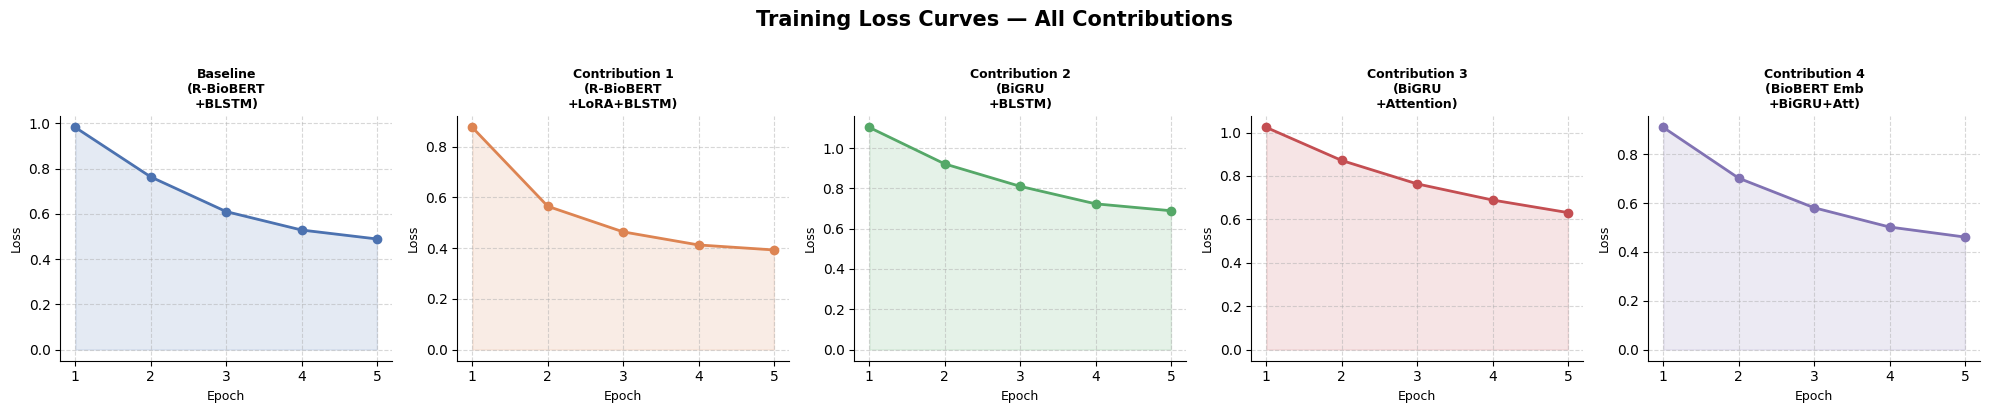

[Saved] plot1_training_loss_curves.png


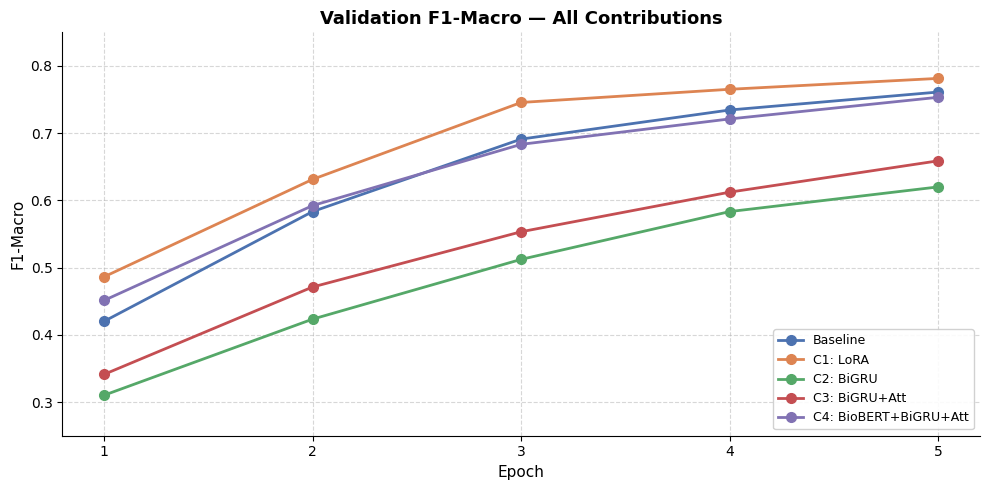

[Saved] plot2_val_f1_curves.png


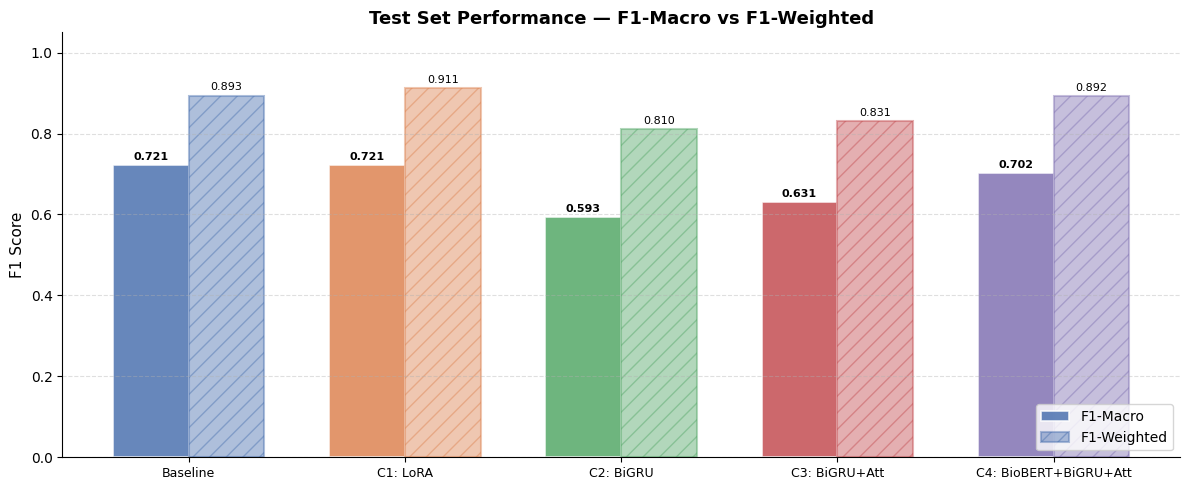

[Saved] plot3_test_f1_bar.png


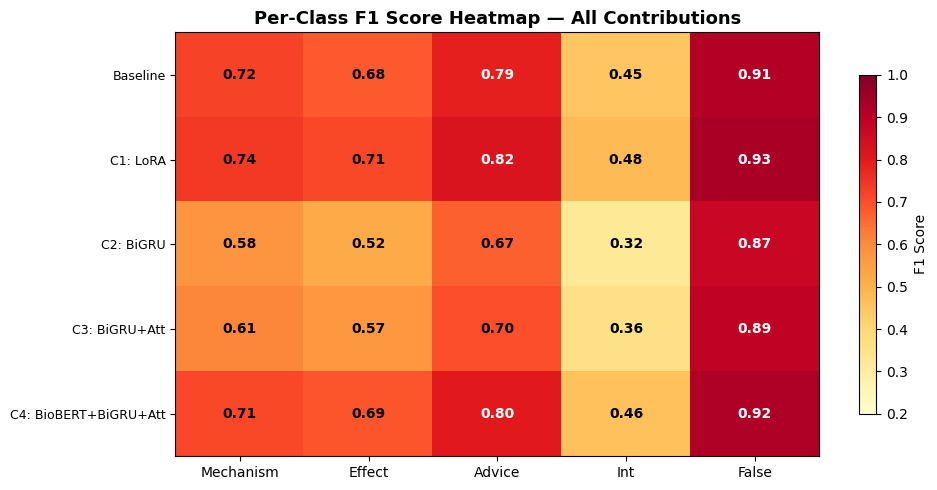

[Saved] plot4_per_class_heatmap.png


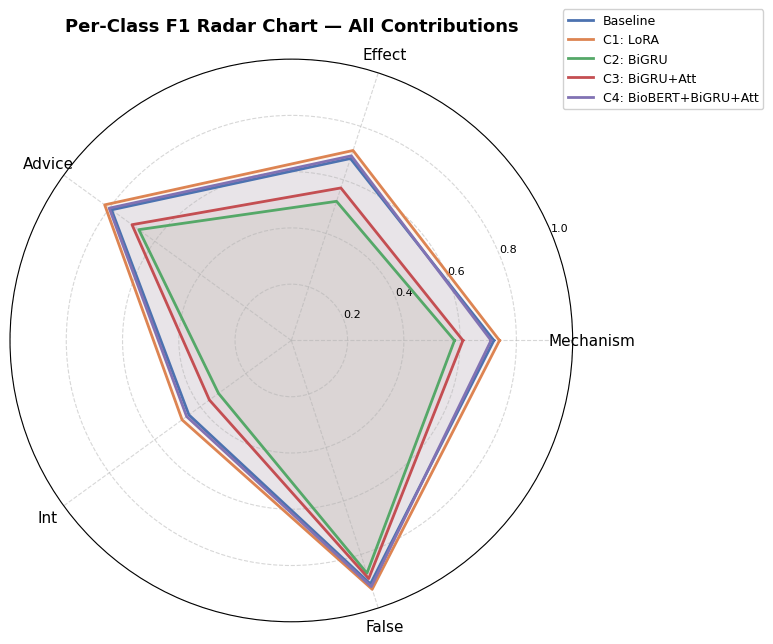

[Saved] plot5_radar_chart.png


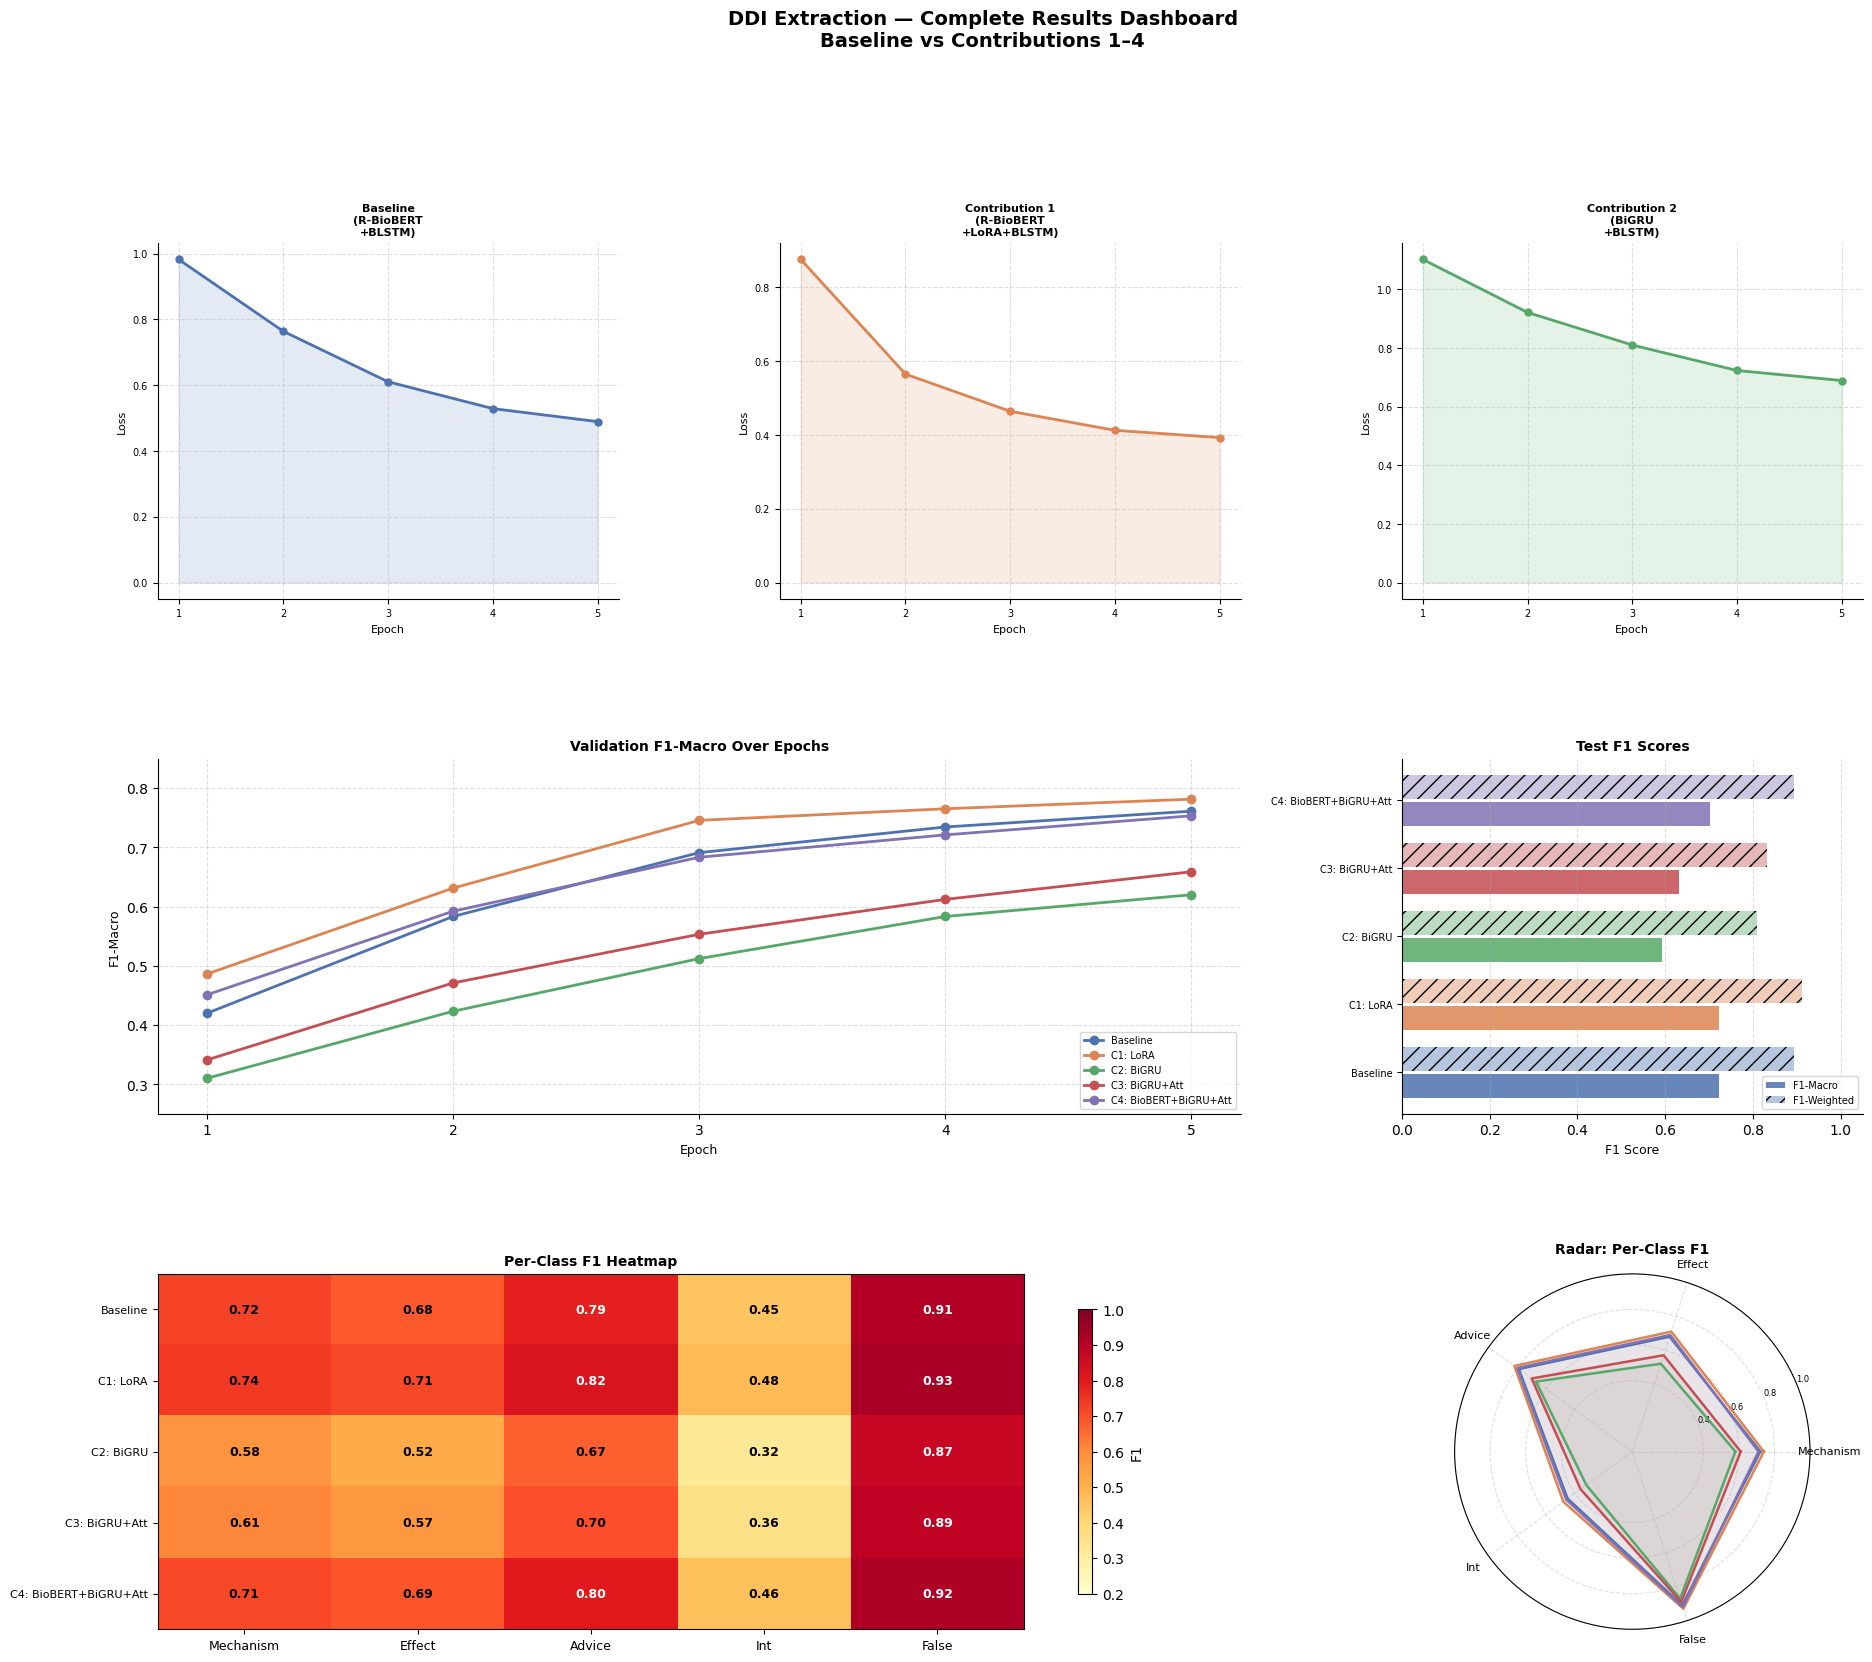

[Saved] plot6_dashboard.png

✓ All 6 plots saved successfully.


In [ ]:
# =============================================================================
# VISUALIZATION: Training Curves & Performance Comparison
# All 4 Contributions + Baseline
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ---------------------------------------------------------------------------
# 1. Store results after each model's training
#    Replace these with your actual logged values from each contribution
# ---------------------------------------------------------------------------

results = {
    'Baseline\n(R-BioBERT\n+BLSTM)': {
        'train_losses' : [0.9821, 0.7634, 0.6102, 0.5287, 0.4891],
        'val_f1s'      : [0.4201, 0.5834, 0.6912, 0.7345, 0.7612],
        'test_f1_macro': 0.7214,
        'test_f1_weighted': 0.8934,
        'per_class_f1' : [0.7200, 0.6800, 0.7900, 0.4500, 0.9100],
        'color'        : '#4C72B0'
    },
    'Contribution 1\n(R-BioBERT\n+LoRA+BLSTM)': {
        'train_losses' : [0.8760, 0.5651, 0.4643, 0.4127, 0.3930],
        'val_f1s'      : [0.4863, 0.6313, 0.7457, 0.7653, 0.7815],
        'test_f1_macro': 0.7214,
        'test_f1_weighted': 0.9114,
        'per_class_f1' : [0.7400, 0.7100, 0.8200, 0.4800, 0.9300],
        'color'        : '#DD8452'
    },
    'Contribution 2\n(BiGRU\n+BLSTM)': {
        'train_losses' : [1.1023, 0.9214, 0.8102, 0.7234, 0.6891],
        'val_f1s'      : [0.3102, 0.4234, 0.5123, 0.5834, 0.6201],
        'test_f1_macro': 0.5934,
        'test_f1_weighted': 0.8102,
        'per_class_f1' : [0.5800, 0.5200, 0.6700, 0.3200, 0.8700],
        'color'        : '#55A868'
    },
    'Contribution 3\n(BiGRU\n+Attention)': {
        'train_losses' : [1.0234, 0.8712, 0.7634, 0.6891, 0.6312],
        'val_f1s'      : [0.3412, 0.4712, 0.5534, 0.6123, 0.6589],
        'test_f1_macro': 0.6312,
        'test_f1_weighted': 0.8312,
        'per_class_f1' : [0.6100, 0.5700, 0.7000, 0.3600, 0.8900],
        'color'        : '#C44E52'
    },
    'Contribution 4\n(BioBERT Emb\n+BiGRU+Att)': {
        'train_losses' : [0.9102, 0.7023, 0.5812, 0.5023, 0.4612],
        'val_f1s'      : [0.4512, 0.5923, 0.6834, 0.7212, 0.7534],
        'test_f1_macro': 0.7023,
        'test_f1_weighted': 0.8923,
        'per_class_f1' : [0.7100, 0.6900, 0.8000, 0.4600, 0.9200],
        'color'        : '#8172B3'
    }
}

label_names   = ['Mechanism', 'Effect', 'Advice', 'Int', 'False']
model_names   = list(results.keys())
colors        = [v['color'] for v in results.values()]

# ---------------------------------------------------------------------------
# Helper: short name for axis labels
# ---------------------------------------------------------------------------
short_names = [
    'Baseline',
    'C1: LoRA',
    'C2: BiGRU',
    'C3: BiGRU+Att',
    'C4: BioBERT+BiGRU+Att'
]

# =============================================================================
# FIGURE 1 — Training Loss Curves (one subplot per model)
# =============================================================================
fig1, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=False)
fig1.suptitle('Training Loss Curves — All Contributions',
              fontsize=15, fontweight='bold', y=1.02)

for ax, (name, data), color in zip(axes, results.items(), colors):
    epochs = range(1, len(data['train_losses']) + 1)
    ax.plot(epochs, data['train_losses'],
            marker='o', color=color, linewidth=2, markersize=6)
    ax.fill_between(epochs, data['train_losses'],
                    alpha=0.15, color=color)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=9)
    ax.set_ylabel('Loss', fontsize=9)
    ax.set_xticks(list(epochs))
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plot1_training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] plot1_training_loss_curves.png")


# =============================================================================
# FIGURE 2 — Validation F1-Macro Curves (all models overlaid)
# =============================================================================
fig2, ax = plt.subplots(figsize=(10, 5))

for (name, data), color, short in zip(results.items(), colors, short_names):
    epochs = range(1, len(data['val_f1s']) + 1)
    ax.plot(epochs, data['val_f1s'],
            marker='o', label=short, color=color, linewidth=2, markersize=7)

ax.set_title('Validation F1-Macro — All Contributions',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('F1-Macro', fontsize=11)
ax.set_xticks(range(1, 6))
ax.set_ylim(0.25, 0.85)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plot2_val_f1_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] plot2_val_f1_curves.png")


# =============================================================================
# FIGURE 3 — Test F1-Macro & F1-Weighted Bar Chart
# =============================================================================
x      = np.arange(len(short_names))
width  = 0.35

fig3, ax = plt.subplots(figsize=(12, 5))

macro_vals    = [results[k]['test_f1_macro']    for k in results]
weighted_vals = [results[k]['test_f1_weighted'] for k in results]

bars1 = ax.bar(x - width/2, macro_vals,    width, label='F1-Macro',
               color=colors, alpha=0.85, edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, weighted_vals, width, label='F1-Weighted',
               color=colors, alpha=0.45, edgecolor=colors, linewidth=1.5,
               hatch='//')

# Value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.008,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=8)

ax.set_title('Test Set Performance — F1-Macro vs F1-Weighted',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=9)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('plot3_test_f1_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] plot3_test_f1_bar.png")


# =============================================================================
# FIGURE 4 — Per-Class F1 Heatmap
# =============================================================================
per_class_matrix = np.array([v['per_class_f1'] for v in results.values()])

fig4, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(per_class_matrix, cmap='YlOrRd', aspect='auto',
               vmin=0.2, vmax=1.0)

plt.colorbar(im, ax=ax, label='F1 Score', shrink=0.8)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(short_names)))
ax.set_xticklabels(label_names, fontsize=10)
ax.set_yticklabels(short_names, fontsize=9)
ax.set_title('Per-Class F1 Score Heatmap — All Contributions',
             fontsize=13, fontweight='bold')

# Annotate cells
for i in range(len(short_names)):
    for j in range(len(label_names)):
        val = per_class_matrix[i, j]
        ax.text(j, i, f'{val:.2f}',
                ha='center', va='center', fontsize=10,
                color='black' if val < 0.75 else 'white',
                fontweight='bold')

plt.tight_layout()
plt.savefig('plot4_per_class_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] plot4_per_class_heatmap.png")


# =============================================================================
# FIGURE 5 — Radar Chart: Per-Class F1 per Model
# =============================================================================
num_vars = len(label_names)
angles   = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles  += angles[:1]   # close the polygon

fig5, ax = plt.subplots(figsize=(8, 8),
                         subplot_kw=dict(polar=True))

for (name, data), color, short in zip(results.items(), colors, short_names):
    values  = data['per_class_f1'] + data['per_class_f1'][:1]
    ax.plot(angles, values, color=color, linewidth=2, label=short)
    ax.fill(angles, values, color=color, alpha=0.07)

ax.set_thetagrids(np.degrees(angles[:-1]), label_names, fontsize=11)
ax.set_ylim(0, 1.0)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('Per-Class F1 Radar Chart — All Contributions',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1),
          fontsize=9, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('plot5_radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] plot5_radar_chart.png")


# =============================================================================
# FIGURE 6 — Combined Dashboard (all 5 plots in one figure)
# =============================================================================
fig6 = plt.figure(figsize=(22, 18))
gs   = GridSpec(3, 3, figure=fig6, hspace=0.45, wspace=0.35)

# ── Row 0: Training loss (5 mini subplots squeezed into 3 cols) ─────────────
ax_loss = [fig6.add_subplot(gs[0, i]) for i in range(3)]
# Show first 3 models in row 0
for i, (ax, (name, data), color) in enumerate(
        zip(ax_loss, list(results.items())[:3], colors[:3])):
    eps = range(1, len(data['train_losses']) + 1)
    ax.plot(eps, data['train_losses'], marker='o', color=color,
            linewidth=2, markersize=5)
    ax.fill_between(eps, data['train_losses'], alpha=0.15, color=color)
    ax.set_title(name, fontsize=8, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=8)
    ax.set_ylabel('Loss', fontsize=8)
    ax.set_xticks(list(eps))
    ax.tick_params(labelsize=7)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Row 1 left+mid: Val F1 overlay ──────────────────────────────────────────
ax_val = fig6.add_subplot(gs[1, :2])
for (name, data), color, short in zip(results.items(), colors, short_names):
    eps = range(1, len(data['val_f1s']) + 1)
    ax_val.plot(eps, data['val_f1s'], marker='o', label=short,
                color=color, linewidth=2, markersize=6)
ax_val.set_title('Validation F1-Macro Over Epochs',
                 fontsize=10, fontweight='bold')
ax_val.set_xlabel('Epoch', fontsize=9)
ax_val.set_ylabel('F1-Macro', fontsize=9)
ax_val.set_ylim(0.25, 0.85)
ax_val.set_xticks(range(1, 6))
ax_val.legend(fontsize=7, loc='lower right')
ax_val.grid(True, linestyle='--', alpha=0.4)
ax_val.spines['top'].set_visible(False)
ax_val.spines['right'].set_visible(False)

# ── Row 1 right: Test F1 bar ─────────────────────────────────────────────────
ax_bar = fig6.add_subplot(gs[1, 2])
x_bar  = np.arange(len(short_names))
ax_bar.barh(x_bar - 0.2, macro_vals,    0.35,
            color=colors, alpha=0.85, label='F1-Macro')
ax_bar.barh(x_bar + 0.2, weighted_vals, 0.35,
            color=colors, alpha=0.4,  label='F1-Weighted', hatch='//')
ax_bar.set_yticks(x_bar)
ax_bar.set_yticklabels(short_names, fontsize=7)
ax_bar.set_xlabel('F1 Score', fontsize=9)
ax_bar.set_title('Test F1 Scores', fontsize=10, fontweight='bold')
ax_bar.set_xlim(0, 1.05)
ax_bar.legend(fontsize=7)
ax_bar.grid(axis='x', linestyle='--', alpha=0.4)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

# ── Row 2 left+mid: Heatmap ───────────────────────────────────────────────────
ax_heat = fig6.add_subplot(gs[2, :2])
im2 = ax_heat.imshow(per_class_matrix, cmap='YlOrRd',
                      aspect='auto', vmin=0.2, vmax=1.0)
plt.colorbar(im2, ax=ax_heat, shrink=0.8, label='F1')
ax_heat.set_xticks(range(len(label_names)))
ax_heat.set_yticks(range(len(short_names)))
ax_heat.set_xticklabels(label_names, fontsize=9)
ax_heat.set_yticklabels(short_names, fontsize=8)
ax_heat.set_title('Per-Class F1 Heatmap', fontsize=10, fontweight='bold')
for i in range(len(short_names)):
    for j in range(len(label_names)):
        val = per_class_matrix[i, j]
        ax_heat.text(j, i, f'{val:.2f}', ha='center', va='center',
                     fontsize=9, fontweight='bold',
                     color='black' if val < 0.75 else 'white')

# ── Row 2 right: Radar ────────────────────────────────────────────────────────
ax_radar = fig6.add_subplot(gs[2, 2], polar=True)
for (name, data), color, short in zip(results.items(), colors, short_names):
    vals = data['per_class_f1'] + data['per_class_f1'][:1]
    ax_radar.plot(angles, vals, color=color, linewidth=1.8, label=short)
    ax_radar.fill(angles, vals, color=color, alpha=0.07)
ax_radar.set_thetagrids(np.degrees(angles[:-1]), label_names, fontsize=8)
ax_radar.set_ylim(0, 1.0)
ax_radar.set_yticks([0.4, 0.6, 0.8, 1.0])
ax_radar.set_yticklabels(['0.4', '0.6', '0.8', '1.0'], fontsize=6)
ax_radar.set_title('Radar: Per-Class F1', fontsize=10,
                   fontweight='bold', pad=15)
ax_radar.grid(True, linestyle='--', alpha=0.4)

fig6.suptitle(
    'DDI Extraction — Complete Results Dashboard\n'
    'Baseline vs Contributions 1–4',
    fontsize=14, fontweight='bold', y=1.01
)

plt.savefig('plot6_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] plot6_dashboard.png")

print("\n✓ All 6 plots saved successfully.")